In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [5]:
train = pd.read_csv("../data/train.csv")
train.head()


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [6]:
train["date"] = pd.to_datetime(train["date"])
train.head()


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [7]:
daily = (
    train.groupby("date")["sales"]
    .sum()
    .reset_index()
    .sort_values("date")
)

daily.head()


,date,sales
0,2013-01-01,2511.618999
1,2013-01-02,496092.417944
2,2013-01-03,361461.231124
3,2013-01-04,354459.677093
4,2013-01-05,477350.121229


In [8]:
daily = daily.set_index("date").asfreq("D")
daily["sales"] = daily["sales"].fillna(0)
daily.head()


,sales
date,
2013-01-01,2511.618999
2013-01-02,496092.417944
2013-01-03,361461.231124
2013-01-04,354459.677093
2013-01-05,477350.121229


In [9]:
daily.isna().sum()
daily.describe()


,sales
count,1.688000e+03
mean,6.360456e+05
std,2.361766e+05
min,0.000000e+00
25%,4.408053e+05
50%,6.316926e+05
75%,7.855799e+05
max,1.463084e+06


In [10]:
(daily["sales"] < 0).sum()



0

In [11]:
data = daily.copy()

data["day_of_week"] = data.index.dayofweek       # 0=Mon, 6=Sun
data["month"] = data.index.month
data["day"] = data.index.day
data["year"] = data.index.year
data["is_weekend"] = (data["day_of_week"] >= 5).astype(int)

data.head()


,sales,day_of_week,month,day,year,is_weekend
date,,,,,,
2013-01-01,2511.618999,1,1,1,2013,0
2013-01-02,496092.417944,2,1,2,2013,0
2013-01-03,361461.231124,3,1,3,2013,0
2013-01-04,354459.677093,4,1,4,2013,0
2013-01-05,477350.121229,5,1,5,2013,1


In [12]:
data["lag_1"] = data["sales"].shift(1)      # yesterday
data["lag_7"] = data["sales"].shift(7)      # same day last week

data["roll_7_mean"] = data["sales"].shift(1).rolling(7).mean()
data["roll_30_mean"] = data["sales"].shift(1).rolling(30).mean()

data = data.dropna()
data.head()


,sales,day_of_week,month,day,year,is_weekend,lag_1,lag_7,roll_7_mean,roll_30_mean
date,,,,,,,,,,
2013-01-31,271254.217996,3,1,31,2013,0,281061.127052,247245.690995,316070.048174,335212.350630
2013-02-01,369402.055266,4,2,1,2013,0,271254.217996,290022.771930,319499.837745,344170.437264
2013-02-02,518887.462705,5,2,2,2013,1,369402.055266,413799.767975,330839.735365,339947.425174
2013-02-03,486336.820180,6,2,3,2013,1,518887.462705,430411.991233,345852.263183,345194.966227
2013-02-04,344308.715017,0,2,4,2013,0,486336.820180,285460.169953,353841.524461,349590.870997


In [13]:
test_days = 90
train_df = data.iloc[:-test_days]
test_df = data.iloc[-test_days:]

X_train = train_df.drop(columns=["sales"])
y_train = train_df["sales"]

X_test = test_df.drop(columns=["sales"])
y_test = test_df["sales"]

X_train.shape, X_test.shape


((1568, 9), (90, 9))

In [14]:
model = HistGradientBoostingRegressor(random_state=42)
model.fit(X_train, y_train)


HistGradientBoostingRegressor(random_state=42)

In [15]:
pred_test = model.predict(X_test)


In [16]:
mae = mean_absolute_error(y_test, pred_test)
rmse = mean_squared_error(y_test, pred_test, squared=False)
mape = np.mean(np.abs((y_test - pred_test) / (y_test + 1e-9))) * 100

mae, rmse, mape


E:\Anaconda\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


(56254.97064223248, 74266.47916755352, 6.417439645961218)

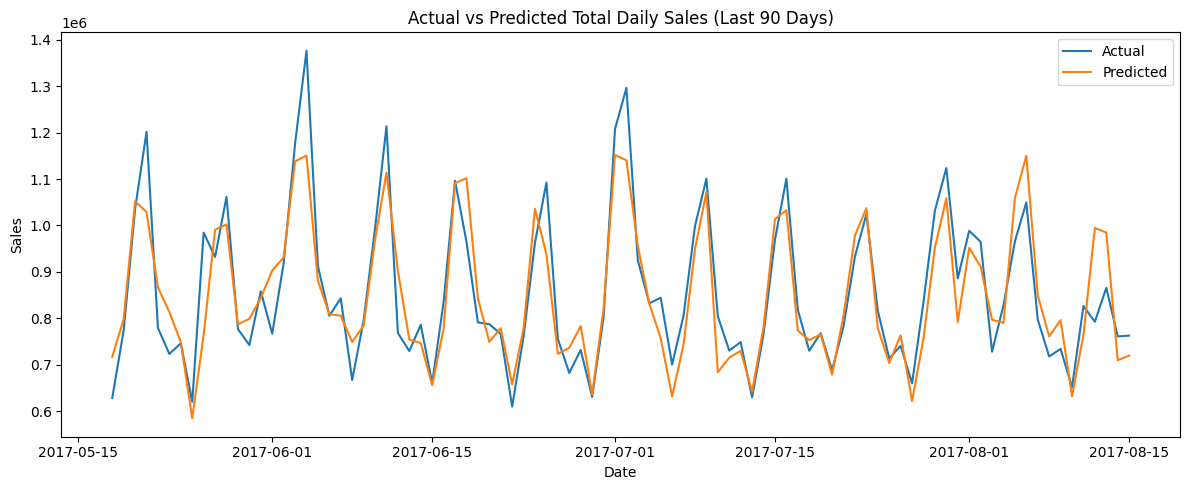

In [17]:
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test.values, label="Actual")
plt.plot(y_test.index, pred_test, label="Predicted")
plt.title("Actual vs Predicted Total Daily Sales (Last 90 Days)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()


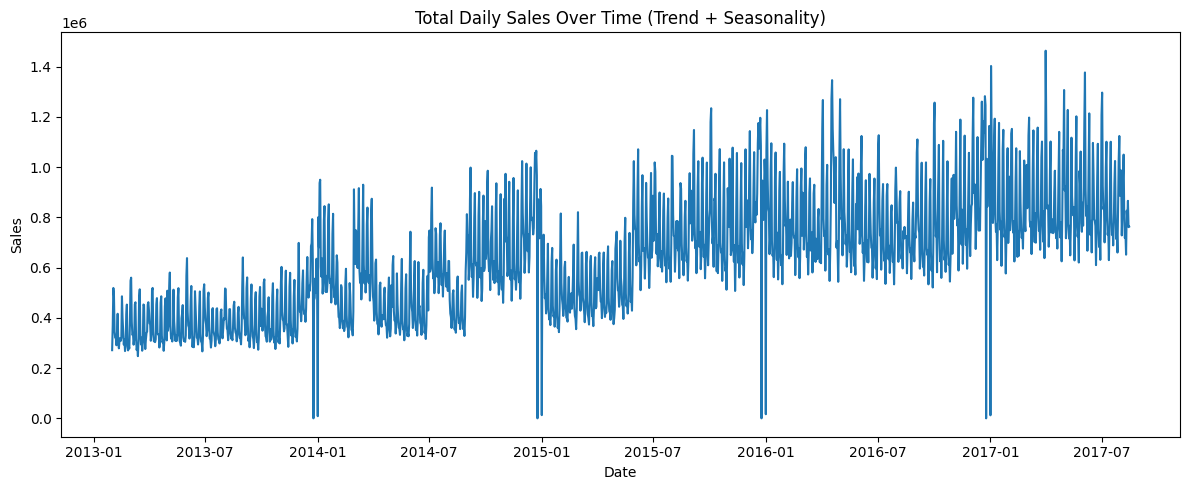

In [18]:
plt.figure(figsize=(12,5))
plt.plot(data.index, data["sales"])
plt.title("Total Daily Sales Over Time (Trend + Seasonality)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()


In [19]:
horizon = 30
last_date = data.index.max()
future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=horizon, freq="D")
future_dates[:5], future_dates[-1]


(DatetimeIndex(['2017-08-16', '2017-08-17', '2017-08-18', '2017-08-19',
                '2017-08-20'],
               dtype='datetime64[ns]', freq='D'),
 Timestamp('2017-09-14 00:00:00'))

In [20]:
history = data[["sales"]].copy()
future_preds = []

for date in future_dates:
    row = pd.DataFrame(index=[date])
    row["day_of_week"] = date.dayofweek
    row["month"] = date.month
    row["day"] = date.day
    row["year"] = date.year
    row["is_weekend"] = int(date.dayofweek >= 5)

    row["lag_1"] = history["sales"].iloc[-1]
    row["lag_7"] = history["sales"].iloc[-7]
    row["roll_7_mean"] = history["sales"].iloc[-7:].mean()
    row["roll_30_mean"] = history["sales"].iloc[-30:].mean()

    pred = model.predict(row)[0]
    future_preds.append(pred)

    history.loc[date, "sales"] = pred

future_forecast = pd.DataFrame({"forecast_sales": future_preds}, index=future_dates)
future_forecast.head()


,forecast_sales
2017-08-16,7.746862e+05
2017-08-17,7.131643e+05
2017-08-18,7.968930e+05
2017-08-19,1.015450e+06
2017-08-20,1.012045e+06


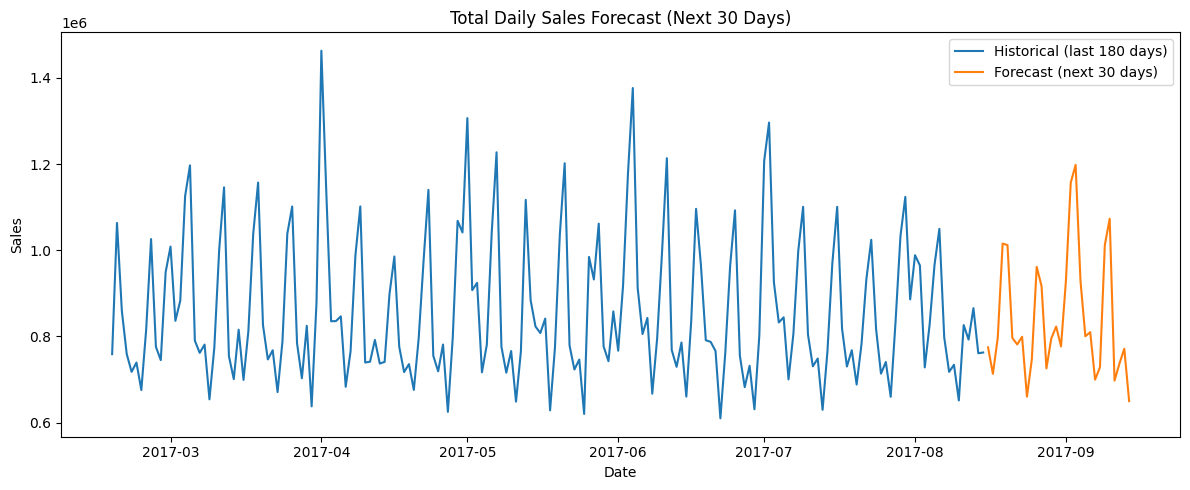

In [21]:
plt.figure(figsize=(12,5))
plt.plot(data.index[-180:], data["sales"].iloc[-180:], label="Historical (last 180 days)")
plt.plot(future_forecast.index, future_forecast["forecast_sales"], label="Forecast (next 30 days)")
plt.title("Total Daily Sales Forecast (Next 30 Days)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.show()


In [22]:
future_forecast.to_csv("../outputs/forecast_next_30_days.csv")


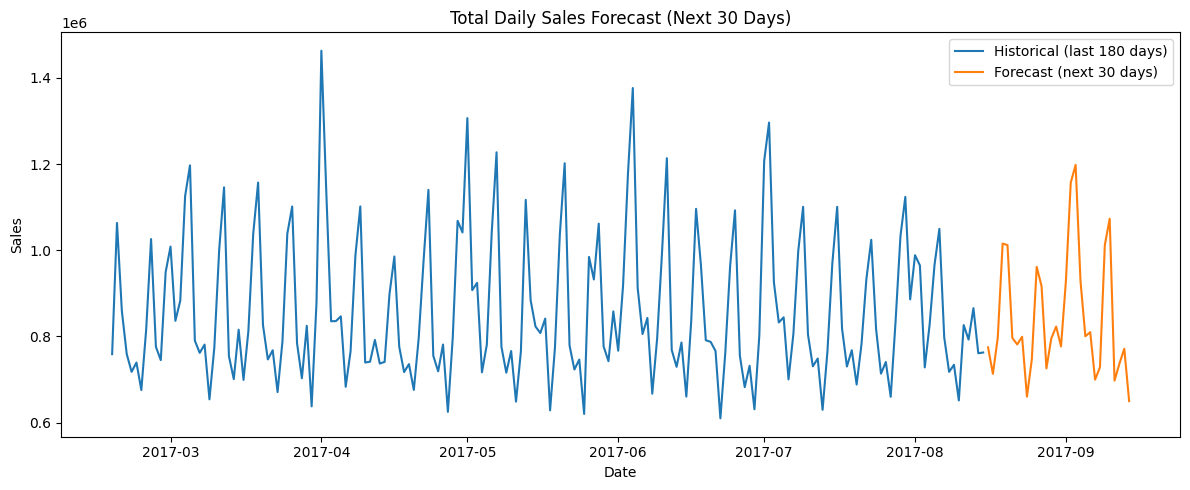

In [23]:
plt.figure(figsize=(12,5))
plt.plot(data.index[-180:], data["sales"].iloc[-180:], label="Historical (last 180 days)")
plt.plot(future_forecast.index, future_forecast["forecast_sales"], label="Forecast (next 30 days)")
plt.title("Total Daily Sales Forecast (Next 30 Days)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/forecast_plot.png", dpi=200)
plt.show()


In [25]:
What the forecast means
This model predicts total daily sales for the next 30 days using historical patterns.
It captures:
weekly seasonality (weekday vs weekend),
recent demand using “yesterday / last week” sales,
trend using rolling averages.
How a business can use it
Inventory: Higher forecast → order more stock to avoid running out.
Staffing: Higher days → schedule more staff; lower days → reduce cost.
Cash flow planning: Forecast helps estimate revenue and plan expenses.
Promotions: If forecast is low, promotions can boost demand.
Model quality (test on last 90 days)
MAE: (paste your MAE number)
MAPE: (paste your MAPE number)
Limitations
Big unexpected events (holidays, disruptions, policy changes) may reduce accuracy.
The model should be retrained regularly as new data arrives.


SyntaxError: invalid syntax (2808584300.py, line 1)